In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
np.random.seed(10)

### Regressão Linear e Superfície de Erro

Uma generalização para qualquer número de atributos, K, é dada pela equação do *hiperplano*:

y_hat = a_0 + sum(a_i * x_i), sendo a somatória de i=1 a i=K

O hiperplano é o primeiro formato de função aproximadora (ou modelo) que iremos usar. O *modelo* é definido pela *equação* e pelos *pesos* a_i

A palavra linear no contexto da regressão significa *linear com relação aos pesos* e não em relação aos atributos

In [24]:
n = 100
X =  np.random.rand(n,2)
y = X[:,0] ** 2 + X[:,1] ** 2 +  np.random.rand(n) # y = x0^2 + x1^2 + noise

X = np.c_[X,np.ones(n)] # bias

Plotando a Superfície de erro e suas curvas de nível

In [25]:
a_0 = np.arange(-1000,1000,4)
a_1 = np.arange(-1000,1000,4)
mse = np.zeros((len(a_0), len(a_1)))


for i, a0 in enumerate(a_0):
    for j, a1 in enumerate(a_1):
        y_hat = a0 * X[:,0] + a1 * X[:,1] + X[:,2]
        mse[i,j] = 1/n * np.linalg.norm(y - y_hat)**2


a_0,a_1 = np.meshgrid(a_0,a_1)

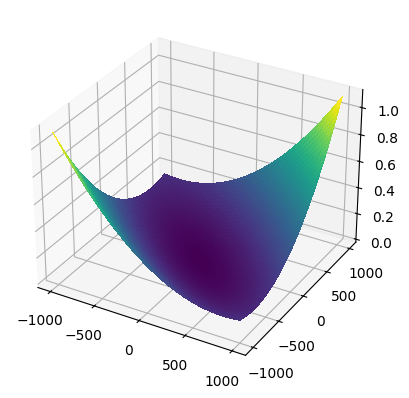

In [26]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

ax.plot_surface(a_0,a_1,mse,cmap=cm.viridis,
                       linewidth=0, antialiased=False) #ploting the surface   

plt.show()

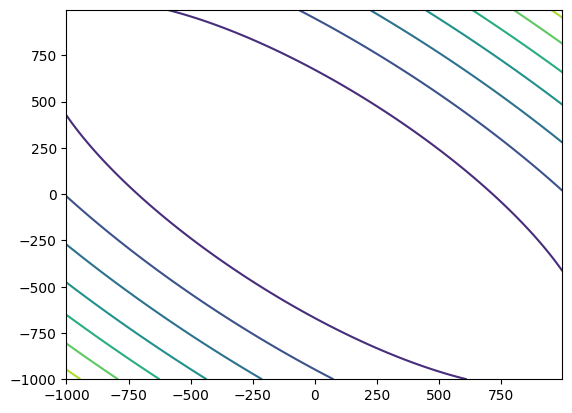

In [27]:
plt.contour(a_0,a_1,mse)
plt.show()

plotando os histogramas de x0 e x1 (não ficou bom como o que está no link do slide)

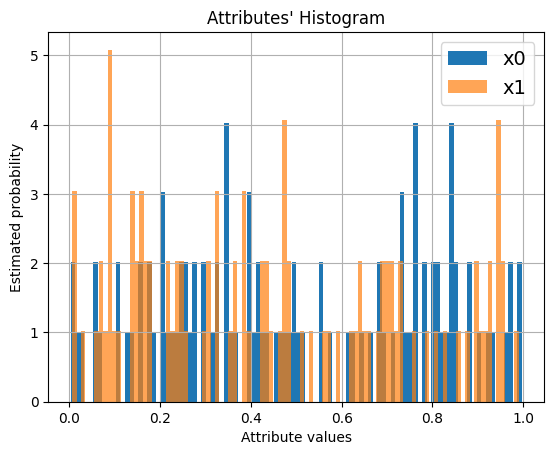

In [29]:
plt.figure()
plt.hist(X[:,0], bins=100, density=True, label='x0')
plt.hist(X[:,1], bins=100, density=True, alpha=0.7, label='x1')
plt.xlabel('Attribute values')
plt.ylabel('Estimated probability')
plt.legend(fontsize=14)
plt.grid()
plt.title('Attributes\' Histogram')
plt.show()

computando os pesos por meio da equação normal

In [30]:
a = np.linalg.inv(X.T @ X) @ X.T @ y
y_hat_sol = X @ a

print(a)

[1.0522606  0.91844542 0.19191594]


Calculando o Erro Quadrático médio da solução

In [31]:
mse_sol = 1/n * sum(np.abs(y - y_hat_sol)**2)
print(mse_sol)

0.09977488479264829


Plotando a solução

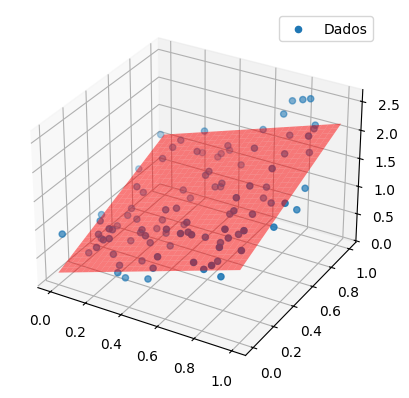

In [33]:
x0, x1 = np.meshgrid(np.linspace(0, 1, 30), np.linspace(0, 1, 30))
y_pred = a[0]*x0 + a[1]*x1 + a[2]

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(X[:,0], X[:,1], y, label='Dados')
ax.plot_surface(x0, x1, y_pred, alpha=0.5, color='red')
plt.legend()
plt.show()

### Regressão Linear e Superfície de Erro (2D)

In [9]:
n = 100
X = 100 * np.random.rand(n)
y = X + 10 + np.random.randn(n)

X = np.c_[X,np.ones(n)] # bias

curva de erro

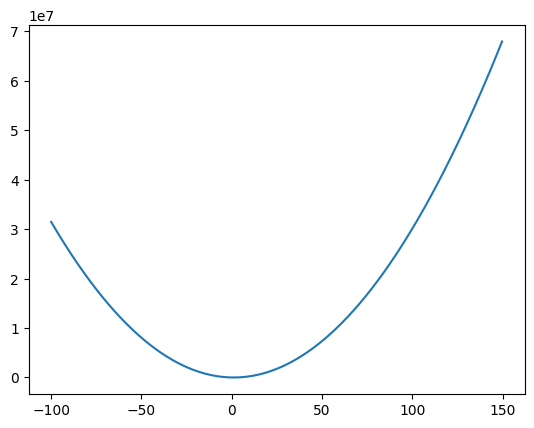

In [10]:
a0 = np.arange(-100,150,0.25)
mse = np.empty(len(a0))

for i,a in enumerate(a0):
    y_hat = a0[i] * X[:,0] + X[:,1]
    mse[i] = 1/n * np.linalg.norm(y-y_hat)**2

plt.plot(a0,mse)
plt.show()

computando os pesos por meio da equação normal

In [11]:
a = np.linalg.inv(X.T @ X) @ X.T @ y
print(a)
y_hat_sol = X @ a


[ 1.00011073 10.02871359]


calculando o erro quadrático médio

In [12]:
mse_sol = 1/n * sum(np.abs(y-y_hat_sol)**2)
print(mse_sol)

0.8114031003526491


Plotando a solução

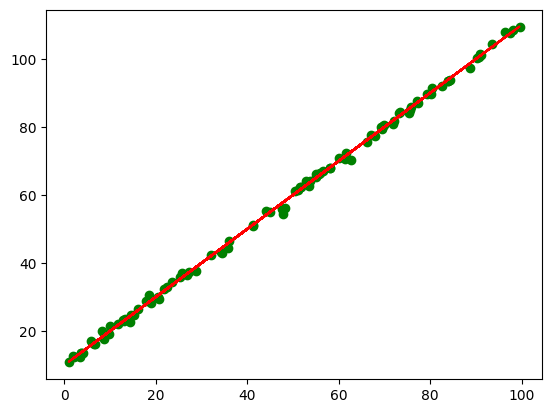

In [14]:
plt.scatter(X[:,0],y,color='green')
plt.plot(X[:,0],y_hat_sol,color='red')
plt.show()

### Exercício 1, Lista 2

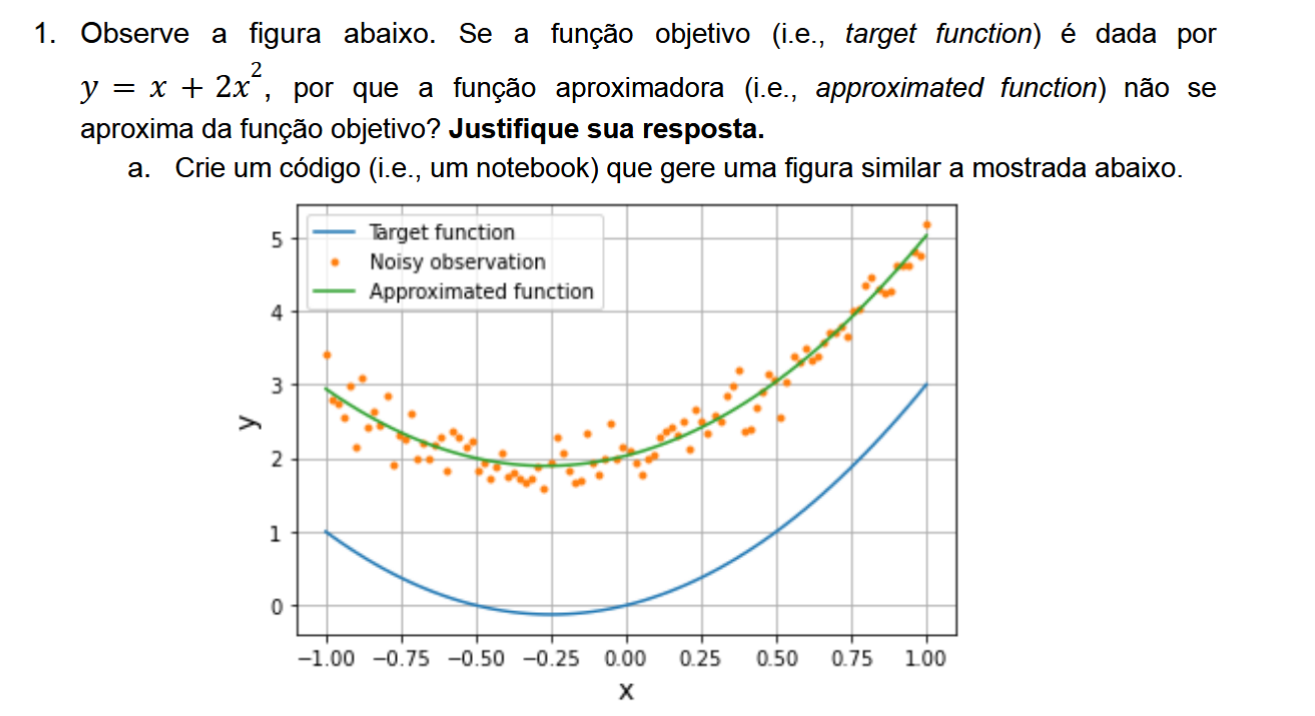

Isso acontece porque a função objetivo (*target function*) não apresenta um termo independente, que a desloque ao longo do eixo y (*bias*), enquanto a função observável (*noisy observation*) e a função aproximadora estão deslocadas verticalmente.

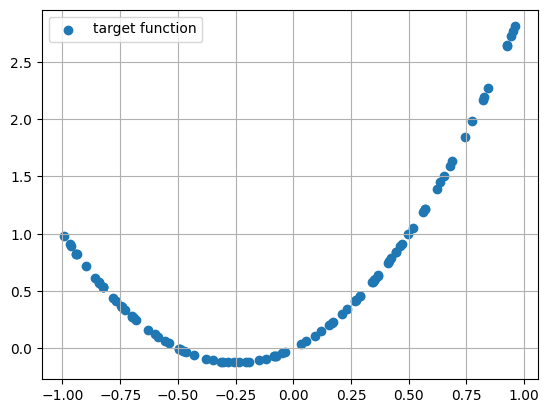

In [93]:
m = 100
x = np.random.uniform(-1,1,size=(m,1))
y_target = x + 2 * x**2
plt.scatter(x,y_target,label='target function')
plt.grid(True)
plt.legend()
plt.show()

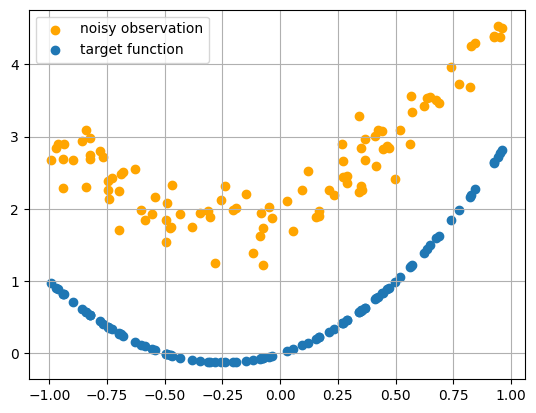

In [94]:
w = np.random.normal(0,0.3,size=(m,1))
y_noisy = y_target + w + 2
plt.scatter(x,y_noisy,color='orange',label='noisy observation')
plt.scatter(x,y_target,label='target function')
plt.grid()
plt.legend()
plt.show()

calculando a funçao hipótese

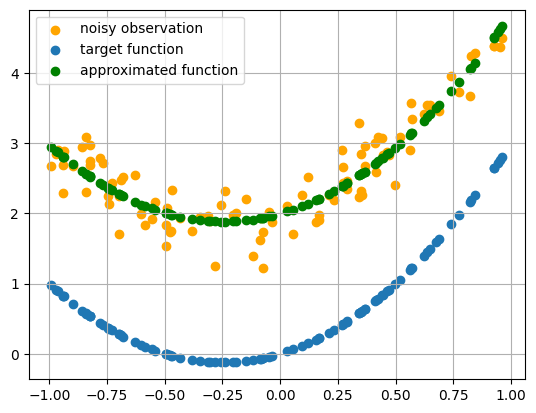

In [95]:
design_matrix = np.c_[x,x**2,np.ones((len(x),1))]
weights = np.linalg.inv(design_matrix.T @ design_matrix) @ design_matrix.T @ y_noisy
y_approximated = design_matrix @ weights
plt.scatter(x,y_noisy,color='orange',label='noisy observation')
plt.scatter(x,y_target,label='target function')
plt.scatter(x,y_approximated,label='approximated function',color='green')
plt.grid()
plt.legend()
plt.show()


### Exercício 2, Lista 2

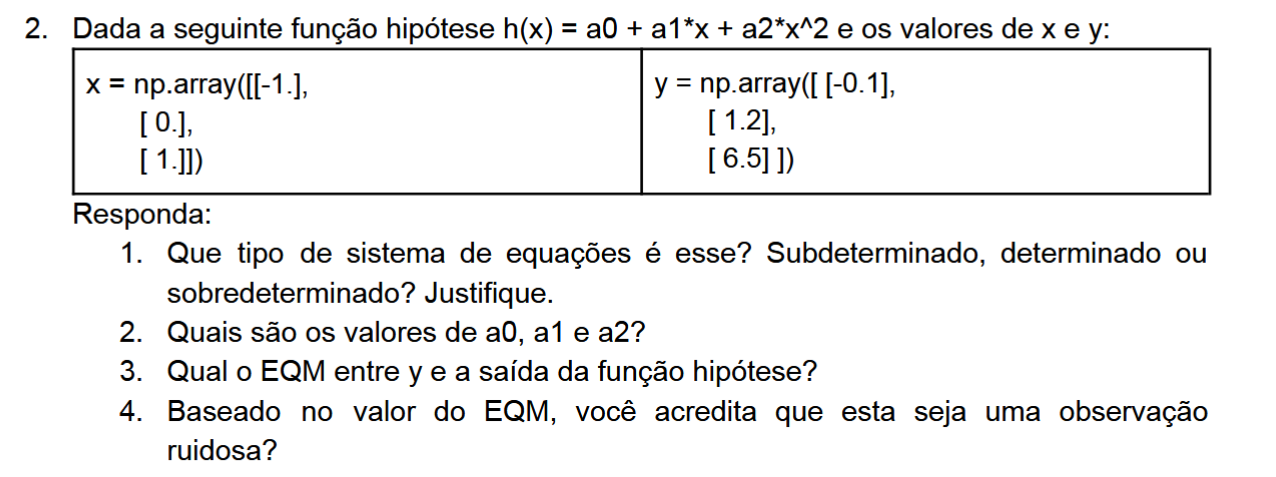

1. Sistema determinado, temos 3 pares ordenados (x,y) e 3 pesos/variáveis (a0,a1,a2)
2. 

In [100]:
x = np.array([[-1.],[0.],[1.]])
y = np.array([[-0.1],[1.2],[6.5]])
x_design = np.c_[np.ones((len(x),1)),x,x**2]
a = np.linalg.inv(x_design.T @ x_design) @ x_design.T @ y
print(a)

[[1.2]
 [3.3]
 [2. ]]


3.

In [101]:
y_hat = x_design @ a
eqm = 1/len(x) * np.linalg.norm(y - y_hat)**2
print(eqm)

1.8745718125369092e-32


4. Como o erro calculado foi extremamente baixo, acredito que essa não seja uma observação ruidosa

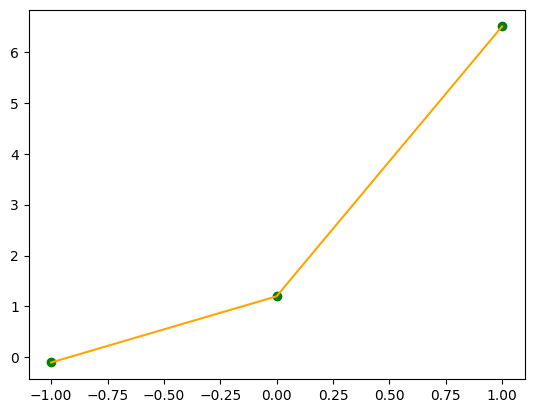

In [103]:
plt.scatter(x,y,color='green',label='observação')
plt.plot(x,y_hat,color = 'orange', label = 'predicao')
plt.show()